In [22]:
# Import required libraries
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import numpy as np
import os
import json
import shutil
import subprocess
import time
import sys
import urllib.request
import zipfile
import requests

# Import PerceptionMetrics components
from perceptionmetrics.datasets.coco import CocoDataset
from perceptionmetrics.models.torch_detection import TorchImageDetectionModel

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [23]:
# Create directories for data
os.makedirs("local/data/datasets", exist_ok=True)
os.makedirs("local/data/models", exist_ok=True)
os.makedirs("local/outputs", exist_ok=True)

# Init TACO ground truth (```CocoDataset```)
TACO stores its ground truth in COCO JSON format, so it does not need to be converted to YOLO TXT files. We provide:
- The TACO COCO annotation JSON.
- The TACO image root (the directory containing the `batch_*` image folders).

The next cell downloads the official TACO repository and then runs its resumable image downloader. Existing files are reused. `CocoDataset.read_annotation()` converts COCO pixel `XYWH` boxes to the common pixel `XYXY` representation. The YOLO postprocessor converts model predictions to the same representation before evaluation.

In [24]:
NUM_IMAGES = 100

taco_dir = "local/data/datasets/TACO"
full_annotation_file = os.path.join(taco_dir, "data", "annotations.json")
annotation_file = os.path.join(taco_dir, "data", "annotations_mini.json")
image_dir = os.path.join(taco_dir, "data")

taco_archive_url = "https://github.com/pedropro/TACO/archive/refs/heads/master.zip"
taco_archive = "local/data/datasets/TACO-master.zip"
extracted_taco_dir = "local/data/datasets/TACO-master"


# ---------------------------------------------------------
# 1. Download official TACO repository if necessary
# ---------------------------------------------------------

if not os.path.isfile(full_annotation_file):

    print("Downloading the official TACO repository...")

    partial_archive = taco_archive + ".part"

    urllib.request.urlretrieve(
        taco_archive_url,
        partial_archive
    )

    os.replace(partial_archive, taco_archive)

    print("Extracting TACO annotations...")

    with zipfile.ZipFile(taco_archive, "r") as archive:
        archive.extractall("local/data/datasets")

    if os.path.isdir(taco_dir):
        shutil.copytree(
            extracted_taco_dir,
            taco_dir,
            dirs_exist_ok=True
        )
        shutil.rmtree(extracted_taco_dir)
    else:
        os.replace(extracted_taco_dir, taco_dir)


# ---------------------------------------------------------
# 2. Load the full TACO COCO annotations
# ---------------------------------------------------------

with open(full_annotation_file, "r") as f:
    taco_annotations = json.load(f)


# ---------------------------------------------------------
# 3. Select only NUM_IMAGES images
# ---------------------------------------------------------

selected_images = taco_annotations["images"][:NUM_IMAGES]

selected_image_ids = {
    image_info["id"]
    for image_info in selected_images
}

selected_annotations = [
    annotation
    for annotation in taco_annotations["annotations"]
    if annotation["image_id"] in selected_image_ids
]


# Build a valid mini COCO annotation file
mini_annotations = {
    "info": taco_annotations.get("info", {}),
    "licenses": taco_annotations.get("licenses", []),
    "images": selected_images,
    "annotations": selected_annotations,
    "categories": taco_annotations["categories"],
}


with open(annotation_file, "w") as f:
    json.dump(mini_annotations, f)

print(
    f"Created mini TACO dataset: "
    f"{len(selected_images)} images, "
    f"{len(selected_annotations)} annotations"
)


# ---------------------------------------------------------
# 4. Download only the selected images
# ---------------------------------------------------------

missing_images = [
    image_info
    for image_info in selected_images
    if not os.path.isfile(
        os.path.join(image_dir, image_info["file_name"])
    )
]

print(f"{len(missing_images)} images still need downloading.")


for index, image_info in enumerate(missing_images, start=1):

    file_path = os.path.join(
        image_dir,
        image_info["file_name"]
    )

    os.makedirs(
        os.path.dirname(file_path),
        exist_ok=True
    )

    # TACO stores the original Flickr URL here
    url = image_info["flickr_url"]

    print(
        f"Downloading [{index}/{len(missing_images)}]: "
        f"{image_info['file_name']}"
    )

    # Retry each image up to 5 times
    for attempt in range(5):

        try:

            response = requests.get(
                url,
                timeout=30
            )

            response.raise_for_status()

            with open(file_path, "wb") as f:
                f.write(response.content)

            break

        except requests.exceptions.RequestException as e:

            print(
                f"Download failed "
                f"(attempt {attempt + 1}/5): {e}"
            )

            if attempt == 4:
                print(
                    f"Skipping image: "
                    f"{image_info['file_name']}"
                )
            else:
                time.sleep(2)


# ---------------------------------------------------------
# 5. Load the mini TACO dataset with PerceptionMetrics
# ---------------------------------------------------------

dataset = CocoDataset(
    annotation_file=annotation_file,
    image_dir=image_dir,
    split="test",
)

print(f"Dataset loaded with {len(dataset.dataset)} samples")
print(f"Number of classes: {len(dataset.ontology)}")

Created mini TACO dataset: 100 images, 302 annotations
0 images still need downloading.
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Dataset loaded with 100 samples
Number of classes: 60


##### We want to check whether the ontology in the stollen model and the original Ground truth are the same

In [25]:
print(dataset.ontology)
from ultralytics import YOLO

model_path = "local/data/models/best.pt"

model = YOLO(model_path)

print("Model classes:")
print(model.names)

print("\nNumber of classes:")
print(len(model.names))

{'Aluminium foil': {'idx': 0, 'rgb': [0, 0, 0]}, 'Battery': {'idx': 1, 'rgb': [0, 0, 0]}, 'Aluminium blister pack': {'idx': 2, 'rgb': [0, 0, 0]}, 'Carded blister pack': {'idx': 3, 'rgb': [0, 0, 0]}, 'Other plastic bottle': {'idx': 4, 'rgb': [0, 0, 0]}, 'Clear plastic bottle': {'idx': 5, 'rgb': [0, 0, 0]}, 'Glass bottle': {'idx': 6, 'rgb': [0, 0, 0]}, 'Plastic bottle cap': {'idx': 7, 'rgb': [0, 0, 0]}, 'Metal bottle cap': {'idx': 8, 'rgb': [0, 0, 0]}, 'Broken glass': {'idx': 9, 'rgb': [0, 0, 0]}, 'Food Can': {'idx': 10, 'rgb': [0, 0, 0]}, 'Aerosol': {'idx': 11, 'rgb': [0, 0, 0]}, 'Drink can': {'idx': 12, 'rgb': [0, 0, 0]}, 'Toilet tube': {'idx': 13, 'rgb': [0, 0, 0]}, 'Other carton': {'idx': 14, 'rgb': [0, 0, 0]}, 'Egg carton': {'idx': 15, 'rgb': [0, 0, 0]}, 'Drink carton': {'idx': 16, 'rgb': [0, 0, 0]}, 'Corrugated carton': {'idx': 17, 'rgb': [0, 0, 0]}, 'Meal carton': {'idx': 18, 'rgb': [0, 0, 0]}, 'Pizza box': {'idx': 19, 'rgb': [0, 0, 0]}, 'Paper cup': {'idx': 20, 'rgb': [0, 0, 0]},

# Init object detection model (```TorchImageDetectionModel```)
We must provide:
- Model path (TorchScript file).
- Model JSON configuration file.
- Ontology JSON file. It defines the classes predicted by the model. Here we assume the YOLO model was trained with the same TACO category IDs as the COCO annotations.

In the following cell we build these files programmatically.

##### Change the model best.pt to best.torchscript

In [26]:
import os
from ultralytics import YOLO

pt_path = "local/data/models/best.pt"

if not os.path.isfile(pt_path):
    raise FileNotFoundError(f"Missing model: {pt_path}")

model = YOLO(pt_path)

print("Number of classes:", len(model.names))
print("Model classes:", model.names)

# Export TorchScript
exported_path = model.export(format="torchscript")

print("Exported to:", exported_path)

Number of classes: 60
Model classes: {0: 'Aluminium foil', 1: 'Battery', 2: 'Aluminium blister pack', 3: 'Carded blister pack', 4: 'Other plastic bottle', 5: 'Clear plastic bottle', 6: 'Glass bottle', 7: 'Plastic bottle cap', 8: 'Metal bottle cap', 9: 'Broken glass', 10: 'Food Can', 11: 'Aerosol', 12: 'Drink can', 13: 'Toilet tube', 14: 'Other carton', 15: 'Egg carton', 16: 'Drink carton', 17: 'Corrugated carton', 18: 'Meal carton', 19: 'Pizza box', 20: 'Paper cup', 21: 'Disposable plastic cup', 22: 'Foam cup', 23: 'Glass cup', 24: 'Other plastic cup', 25: 'Food waste', 26: 'Glass jar', 27: 'Plastic lid', 28: 'Metal lid', 29: 'Other plastic', 30: 'Magazine paper', 31: 'Tissues', 32: 'Wrapping paper', 33: 'Normal paper', 34: 'Paper bag', 35: 'Plastified paper bag', 36: 'Plastic film', 37: 'Six pack rings', 38: 'Garbage bag', 39: 'Other plastic wrapper', 40: 'Single-use carrier bag', 41: 'Polypropylene bag', 42: 'Crisp packet', 43: 'Spread tub', 44: 'Tupperware', 45: 'Disposable food con

In [ ]:
# Load the model
model_path = "local/data/models/best.torchscript"

# Config path
config_path = "local/data/models/best_config.json"

# Model ontology path
ontology_path = "local/data/models/taco_model_ontology.json"

model_url = os.environ.get("TACO_MODEL_URL")

if not os.path.isfile(model_path):
    if not model_url:
        raise FileNotFoundError(
            f"{model_path} is missing. Set TACO_MODEL_URL to the download URL "
            "of a YOLO TorchScript model trained with the official TACO category IDs."
        )

    print("Downloading the TACO YOLO TorchScript model...")
    partial_model = model_path + ".part"
    urllib.request.urlretrieve(model_url, partial_model)
    os.replace(partial_model, model_path)

model_cfg = {
    "batch_size": 1,
    "num_workers": 0,
    "confidence_threshold": 0.05,
    "nms_threshold": 0.5,
    "model_format": "yolo",

    "resize": {
        "height": 640,
        "width": 640
    }
}

with open(config_path, "w") as f:
    json.dump(model_cfg, f, indent=2)

print(model_cfg)

{'batch_size': 1, 'num_workers': 0, 'confidence_threshold': 0.5, 'nms_threshold': 0.5, 'model_format': 'yolo', 'resize': {'height': 640, 'width': 640}}


In [28]:
detection_model = TorchImageDetectionModel(
    model=model_path,
    model_cfg=config_path,
    ontology_fname=ontology_path
)

print("Detection model initialized!")
print(detection_model.transform_input)

Detection model initialized!
Compose(
      Resize(size=[640, 640], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
)


# Single inference example

In [29]:
# Function to visualize detection results
def visualize_detections(image, predictions, ground_truth=None, title="Detection Results"):
    """Visualize detection predictions and optionally ground truth."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Display image
    ax.imshow(image)

    # Map labels to class names
    label_to_name = {v['idx'] : k for k, v in dataset.ontology.items()}

    # Draw prediction boxes
    if predictions and isinstance(predictions, dict) and 'boxes' in predictions:
        boxes = predictions['boxes'].cpu().numpy()
        scores = predictions['scores'].cpu().numpy()
        labels = predictions['labels'].cpu().numpy()

        for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
            # Convert [x1, y1, x2, y2] to [x, y, width, height]
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            # Get class name
            class_name = label_to_name.get(label, str(label))

            # Create rectangle patch
            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor='red', facecolor='none', alpha=0.7
            )
            ax.add_patch(rect)

            # Add label
            txt = ax.text(
                x1,
                y1 - 5,
                f"{class_name}: {score:.2f}",
                color="red",
                fontsize=10,
                # weight="bold",
            )
            txt.set_path_effects(
                [
                    path_effects.Stroke(linewidth=1, foreground="white"),
                    path_effects.Normal(),
                ]
            )

    # Draw ground truth boxes (if provided)
    if ground_truth and isinstance(ground_truth, tuple) and len(ground_truth) >= 2:
        gt_boxes, gt_labels = ground_truth

        for i, (box, label) in enumerate(zip(gt_boxes, gt_labels)):
            # Convert [x1, y1, x2, y2] to [x, y, width, height]
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1

            # Get class name
            class_name = label_to_name.get(label, str(label))

            rect = patches.Rectangle(
                (x1, y1), width, height,
                linewidth=2, edgecolor='green', facecolor='none', alpha=0.7
            )
            ax.add_patch(rect)

            txt = ax.text(
                x1,
                y1 + height + 5,
                f"GT: {class_name}",
                color="green",
                fontsize=10,
            )
            txt.set_path_effects(
                [
                    path_effects.Stroke(linewidth=1, foreground="white"),
                    path_effects.Normal(),
                ]
            )

    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

Testing inference on: /home/sally/PerceptionMetrics/examples/local/data/datasets/TACO/data/batch_1/000006.jpg
Original image size: (1537, 2049)
Cropped image size: (1536, 2048)
Found 0 detections
Ground truth: 1 objects


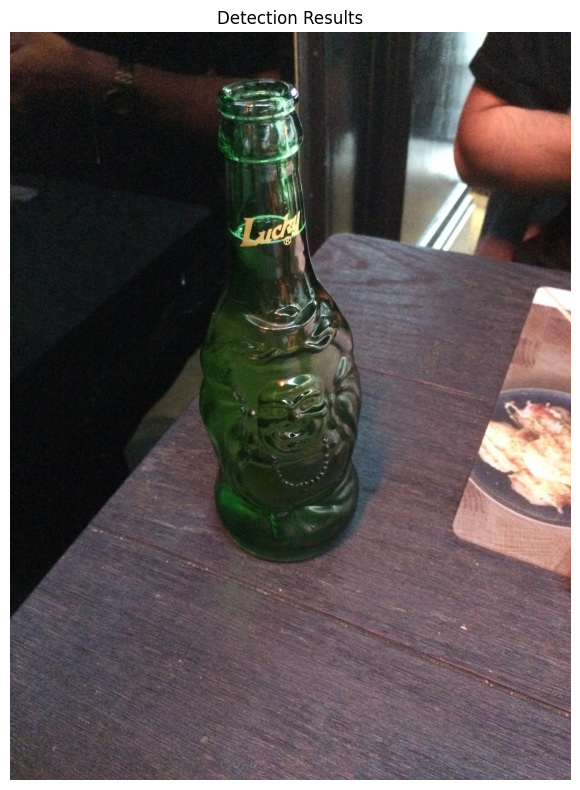

In [30]:
# Test inference on a single image
if 'dataset' in locals() and dataset is not None:
    dataset.make_fname_global()

    sample_idx = 0
    image_path = dataset.dataset.iloc[sample_idx]['image']

    # Load image
    image = Image.open(image_path).convert('RGB')

    print(f"Testing inference on: {image_path}")
    print(f"Original image size: {image.size}")

    # Crop image dimensions down to multiples of 32
    # If already divisible by 32, the image is left unchanged
    w, h = image.size
    new_w = w - (w % 32)
    new_h = h - (h % 32)

    if new_w != w or new_h != h:
        image = image.crop((0, 0, new_w, new_h))
        print(f"Cropped image size: {image.size}")
    else:
        print("Image size already divisible by 32, no cropping needed.")

    # Run inference
    predictions = detection_model.predict(image)

    print(f"Found {len(predictions['boxes'])} detections")

    # Load ground truth
    annotation_path = dataset.dataset.iloc[sample_idx]['annotation']
    ground_truth = dataset.read_annotation(annotation_path)

    print(f"Ground truth: {len(ground_truth[0])} objects")

    # Visualize predictions
    visualize_detections(
        image,
        predictions,
        detection_model.ontology
    )

 Testing inference on: 000006.jpg
   Image size: (1537, 2049)
 Found 0 detections
 Ground truth: 1 objects


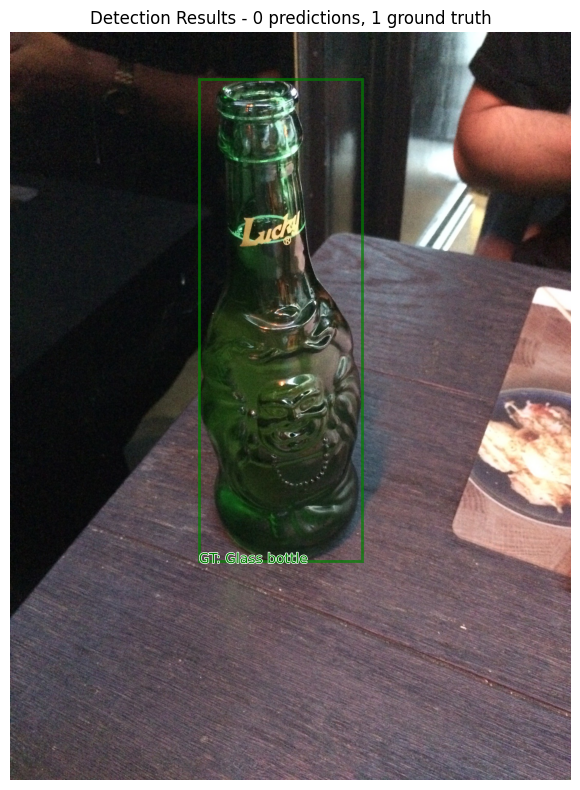

In [31]:
# Test inference on a single image
if 'dataset' in locals() and len(dataset.dataset) > 0:
    # Make filenames global first
    dataset.make_fname_global()

    # Get first image from dataset
    for sample_idx in range(0, 10, 10):
        sample = dataset.dataset[dataset.dataset["split"] == "test"].iloc[sample_idx]
        image_path = sample['image']

        # Load and display original image
        image = Image.open(image_path).convert('RGB')
        print(f" Testing inference on: {os.path.basename(image_path)}")
        print(f"   Image size: {image.size}")

        # Run inference
        predictions = detection_model.predict(image)

        print(f" Found {len(predictions['boxes'])} detections")
        # Get ground truth for comparison
        annotation_path = sample["annotation"]
        ground_truth = dataset.read_annotation(annotation_path)

        print(f" Ground truth: {len(ground_truth[0])} objects")

        # Visualize results
        visualize_detections(
            np.array(image),
            predictions,
            ground_truth,
            title=f"Detection Results - {len(predictions['boxes'])} predictions, {len(ground_truth[0])} ground truth"
        )
else:
    print(" Dataset not loaded. Please check the data paths above.")

In [32]:
# Run evaluation on a subset of the dataset
# For demonstration, we'll use a small subset
if 'dataset' in locals():

    # Make sure the output directory exists
    predictions_outdir = "local/outputs/detection_preds"
    os.makedirs(predictions_outdir, exist_ok=True)

    try:
        # Run evaluation with ontology translation
        results = detection_model.eval(
            dataset=dataset,
            split="test",
            predictions_outdir=predictions_outdir,
            results_per_sample=True
        )

        print(" Evaluation completed!")

    except Exception as e:
        print(f" Evaluation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("  Dataset not loaded. Please check the data paths above.")


  0%|          | 0/100 [00:00<?, ?it/s]

 Evaluation completed!



Metrics DataFrame:


,mean,Aluminium foil,Battery,Aluminium blister pack,Carded blister pack,Other plastic bottle,Clear plastic bottle,Glass bottle,Plastic bottle cap,Metal bottle cap,...,Pop tab,Rope & strings,Scrap metal,Shoe,Squeezable tube,Plastic straw,Paper straw,Styrofoam piece,Unlabeled litter,Cigarette
AP,0.001894,0.0,0.0,0.0,NaN,0.0,0.090909,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Precision,0.020833,0.0,0.0,0.0,NaN,0.0,1.000000,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Recall,0.001488,0.0,0.0,0.0,NaN,0.0,0.071429,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TP,0.020833,0.0,0.0,0.0,NaN,0.0,1.000000,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FP,0.000000,0.0,0.0,0.0,NaN,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FN,6.270833,6.0,1.0,1.0,NaN,12.0,13.000000,8.0,21.0,5.0,...,21.0,1.0,NaN,2.0,3.0,3.0,1.0,3.0,4.0,27.0
mAP@[0.5:0.95],0.001894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AUC-PR,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


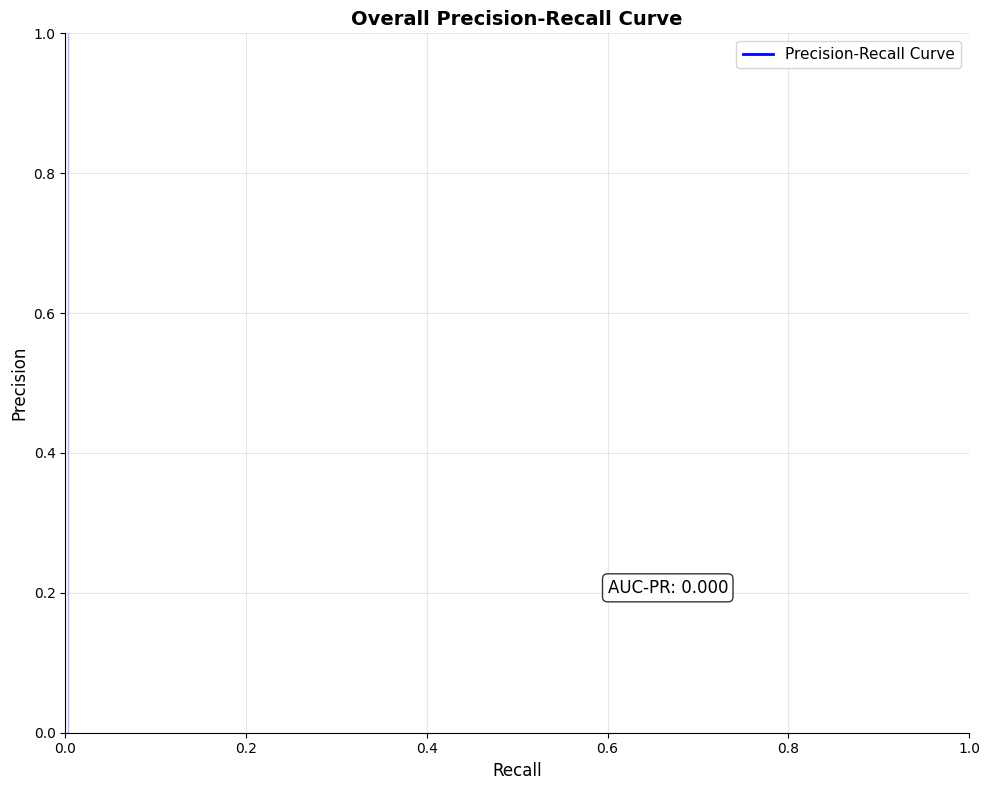

Precision-Recall Curve plotted with AUC-PR: 0.000


In [33]:
# Check the structure of results
if isinstance(results, dict):
    metrics_df = results["metrics_df"]
    metrics_factory = results["metrics_factory"]
else:
    # Fallback for old format
    metrics_df = results
    metrics_factory = None

# Display the metrics DataFrame
print("\nMetrics DataFrame:")

cols = list(metrics_df.columns)
last_col = cols[-1]
new_order = [last_col] + cols[:-1]
metrics_df = metrics_df[new_order]

display(metrics_df)

# Visualize Precision-Recall Curve if metrics factory is available
if metrics_factory is not None:
    # Get the precision-recall curve data
    curve_data = metrics_factory.get_overall_precision_recall_curve()
    auc_pr = metrics_factory.compute_auc_pr()

    # Create the plot
    plt.figure(figsize=(10, 8))

    # Plot the precision-recall curve
    plt.plot(
        curve_data["recall"],
        curve_data["precision"],
        linewidth=2,
        color="blue",
        label="Precision-Recall Curve",
    )

    # Fill the area under the curve
    plt.fill_between(
        curve_data["recall"], curve_data["precision"], alpha=0.3, color="blue"
    )

    # Add AUC-PR annotation
    plt.text(
        0.6,
        0.2,
        f"AUC-PR: {auc_pr:.3f}",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    # Customize the plot
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Overall Precision-Recall Curve", fontsize=14, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)

    # Set axis limits
    plt.xlim([0, 1])
    plt.ylim([0, 1])

    # Add some styling
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f"Precision-Recall Curve plotted with AUC-PR: {auc_pr:.3f}")

else:
    print("Precision-recall curve data not available.")
    print("The evaluation results don't contain the metrics factory object.")

    # Alternative: Show the metrics DataFrame
    if hasattr(metrics_df, "index") and "AP" in metrics_df.index:
        print("\nAvailable metrics:")
        for metric in metrics_df.index:
            if metric in ["AP", "mAP@[0.5:0.95]", "AUC-PR"]:
                mean_value = metrics_df.loc[metric, "mean"]
                print(f"{metric}: {mean_value:.3f}")